In [59]:
from mesa import Agent, Model

from mesa.space import SingleGrid

from mesa.datacollection import DataCollector

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

import numpy as np
import pandas as pd

In [60]:
#class FirefighterAgent(Agent):

In [61]:
class FireRescueModel(Model):
    def __init__(self, columns, rows, num_players):
        super().__init__()

        self.columns = columns
        self.rows = rows

        # Grid para los bomberos (agentes)
        self.FigthersGrid = SingleGrid(columns, rows, torus=False)

        # Matriz para los objetos de tipo fuego/humo
        self.fireCells = np.zeros((rows, columns), dtype=int)

        # Matriz para los objetos de tipo paredes y puertas
        self.wallCells = np.zeros((rows, columns), dtype=int)

        # Coordenadas de las paredes iniciales
        # paredes horizontales: ubicadas con la celda de arriba


        # Coordenadas de fuegos existentes al inicio del fuego
        # (renglon, columna)
        initialFires = [
            (2, 2),
            (2, 3),
            (3, 2),
            (3, 3),
            (3, 4),
            (3, 5),
            (4, 4),
            (5, 6),
            (5, 7),
            (6, 6)
        ]

        for renglon, columna in initialFires:
            self.fireCells[renglon, columna] = 2  # 2 equivale a fuego


    def advanceFire(self):
        # Simula el tiro de dados para ir a la casilla
        # donde debe avanzar el fuego
        renglon = self.random.randrange(self.rows)
        columna = self.random.randrange(self.columns)

        if self.fireCells[renglon, columna] == 0:
            # No hay ni fuego ni humo en la casilla
            if self.check_adjacentFires(renglon, columna):
                self.fireCells[renglon, columna] = 2
                # Si hay fuegos adyacentes se añade fuego
            else:
                self.fireCells[renglon, columna] = 1
                # Si no hay fuegos adyacentes se añade humo

        elif self.fireCells[renglon, columna] == 1:
            # Hay humo en la casilla, se añade fuego
            self.fireCells[renglon, columna] = 2

        elif self.fireCells[renglon, columna] == 2:
            # Hay fuego en la casilla, se genera una explosión
            self.explosion(renglon, columna)


    def check_adjacentFires(self, renglon, columna):
        # Coordenadas adyacentes dentro de la matriz
        neighbors = [
            (renglon - 1, columna),  # arriba
            (renglon + 1, columna),  # abajo
            (renglon, columna - 1),  # izquierda
            (renglon, columna + 1)   # derecha
        ]

        for neighbor_row, neighbor_column in neighbors:

            # Revisa que la coordenada esté dentro de la matriz
            if (0 <= neighbor_row < self.rows and
                0 <= neighbor_column < self.columns):

                if self.fireCells[neighbor_row, neighbor_column] == 2:
                    return True

        return False


    # def explosion(renglon, columna):

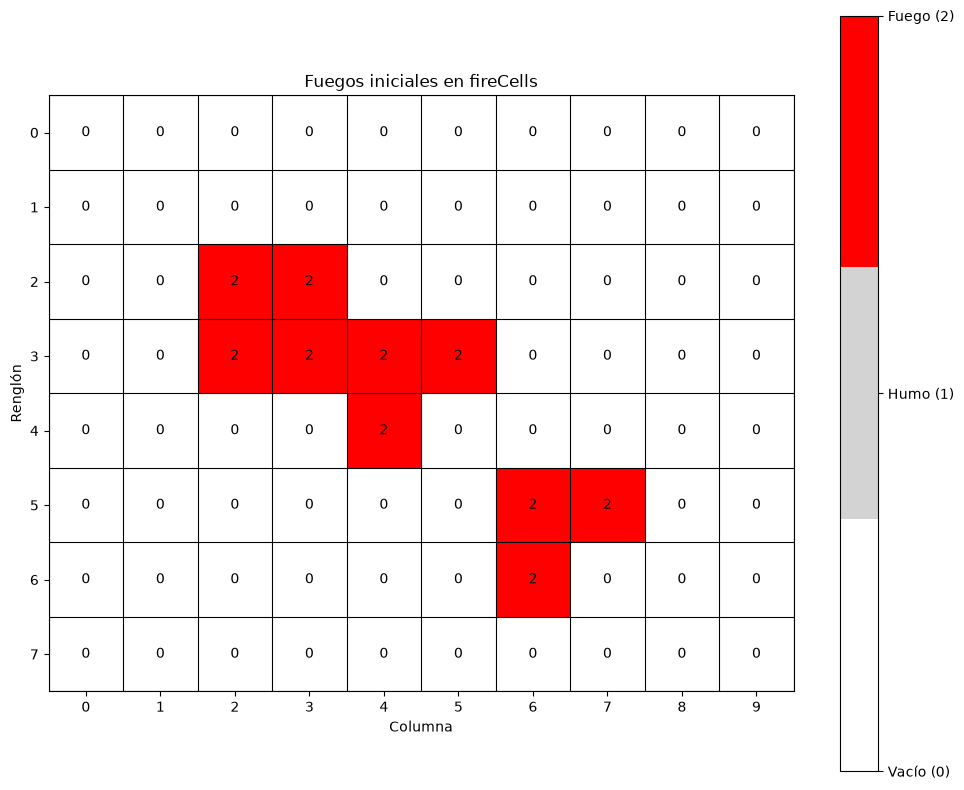

In [62]:
columns = 10
rows = 8
num_players = 6  # ejemplo

model = FireRescueModel(columns, rows, num_players)

# Muestra la matriz de los fuegos, igual al tablero inicial del juego
fig, axis = plt.subplots(figsize=(10, 8))

image = axis.imshow(
    model.fireCells,
    origin="upper",
    cmap=matplotlib.colors.ListedColormap(["white", "lightgray", "red"]),
    vmin=0,
    vmax=2
)

axis.set_title("Fuegos iniciales en fireCells")
axis.set_xlabel("Columna")
axis.set_ylabel("Renglón")

axis.set_xticks(range(columns))
axis.set_yticks(range(rows))

axis.set_xticks(np.arange(-0.5, columns, 1), minor=True)
axis.set_yticks(np.arange(-0.5, rows, 1), minor=True)

axis.grid(which="minor", color="black", linewidth=0.8)
axis.tick_params(which="minor", bottom=False, left=False)

for renglon in range(rows):
    for columna in range(columns):
        axis.text(
            columna,
            renglon,
            str(model.fireCells[renglon, columna]),
            ha="center",
            va="center"
        )

colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Vacío (0)", "Humo (1)", "Fuego (2)"])

fig.tight_layout()
plt.show()